In [1]:
# Importing the main library we need for working with tabular data
import pandas as pd

# Loading the CSV file into a DataFrame
# NOTE: update this path to wherever the file is saved on your computer
df = pd.read_csv("C:/Users/khush_8qg3d62/OneDrive/Desktop/heart_disease_health_indicators_BRFSS2015.csv")

df.head()

C:\Users\khush_8qg3d62\.anaconda\kjoana\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\khush_8qg3d62\.anaconda\kjoana\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
# How many rows and columns do we have?
# (rows = number of survey respondents, columns = number of variables recorded)
df.shape

(253680, 22)

In [3]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 23899


In [4]:
# Check for invalid BMI values (BMI should never be 0 or negative)
invalid_bmi_count = df[df["BMI"] <= 0].shape[0]
print("Invalid BMI values found:", invalid_bmi_count)

Invalid BMI values found: 0


In [6]:
# Remove duplicate rows, keeping only the first occurrence
df = df.drop_duplicates()

# Confirm they're gone
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 229781


In [7]:
# Many columns in this dataset are really categories (Yes/No, or coded groups),
# not continuous numbers, even though they're stored as 0/1/2 etc.
# Converting them to "category" type makes our analysis and charts more accurate.
categorical_cols = [
    "HeartDiseaseorAttack", "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "Diabetes", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex", "Age", "Education", "Income", "GenHlth"
]
df[categorical_cols] = df[categorical_cols].astype("category")

# Confirm the conversion worked and see a summary of column types
df.dtypes

HeartDiseaseorAttack    category
HighBP                  category
HighChol                category
CholCheck               category
BMI                      float64
Smoker                  category
Stroke                  category
Diabetes                category
PhysActivity            category
Fruits                  category
Veggies                 category
HvyAlcoholConsump       category
AnyHealthcare           category
NoDocbcCost             category
GenHlth                 category
MentHlth                 float64
PhysHlth                 float64
DiffWalk                category
Sex                     category
Age                     category
Education               category
Income                  category
dtype: object

In [8]:
# Build a simple summary table
total_records = len(df)
heart_disease_cases = df["HeartDiseaseorAttack"].astype(int).sum()
heart_disease_rate = round((heart_disease_cases / total_records) * 100, 2)

summary = pd.DataFrame({
    "Total Records": [total_records],
    "Heart Disease Cases": [heart_disease_cases],
    "Heart Disease Rate (%)": [heart_disease_rate]
})
summary

,Total Records,Heart Disease Cases,Heart Disease Rate (%)
0,229781,23717,10.32



#We use `matplotlib` and `seaborn` (two popular charting libraries) to see patterns visually.

In [9]:
# Import charting libraries
import matplotlib.pyplot as plt
import seaborn as sns

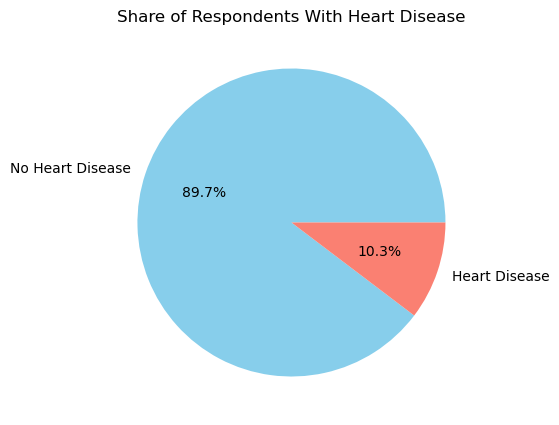

In [10]:
# Chart 1: How many people have heart disease vs. not (as a pie chart)
counts = df["HeartDiseaseorAttack"].value_counts()
labels = ["No Heart Disease", "Heart Disease"]

plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Share of Respondents With Heart Disease")
plt.show()

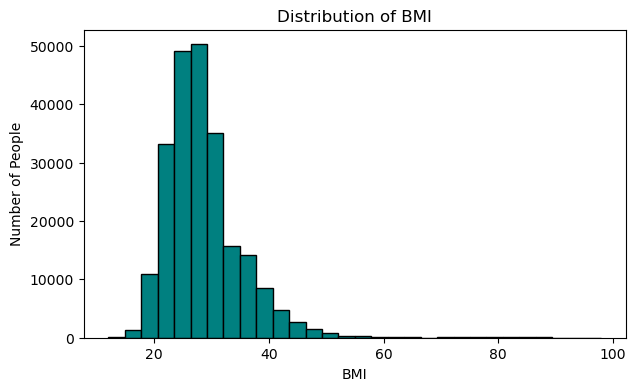

In [11]:
# Chart 2: BMI distribution (a histogram shows how values are spread out)
plt.figure(figsize=(7,4))
plt.hist(df["BMI"], bins=30, color="teal", edgecolor="black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of People")
plt.show()

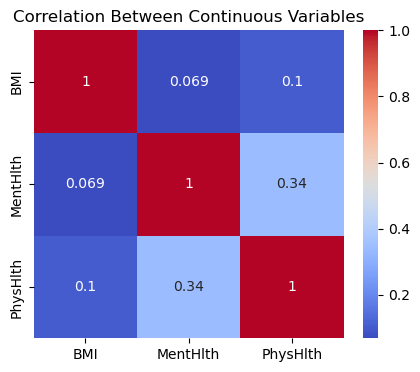

In [12]:
# Chart 3: Correlation heatmap
# This shows which numeric variables move together (closer to 1 or -1 = stronger relationship)
continuous_vars = ["BMI", "MentHlth", "PhysHlth"]
plt.figure(figsize=(5,4))
sns.heatmap(df[continuous_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Continuous Variables")
plt.show()

Heart disease rate by Age group:
Age
1.0      0.5
2.0      0.8
3.0      1.3
4.0      1.6
5.0      2.5
6.0      4.1
7.0      6.2
8.0      8.2
9.0     11.3
10.0    14.2
11.0    17.7
12.0    20.0
13.0    24.6
Name: HeartDiseaseorAttack, dtype: float64


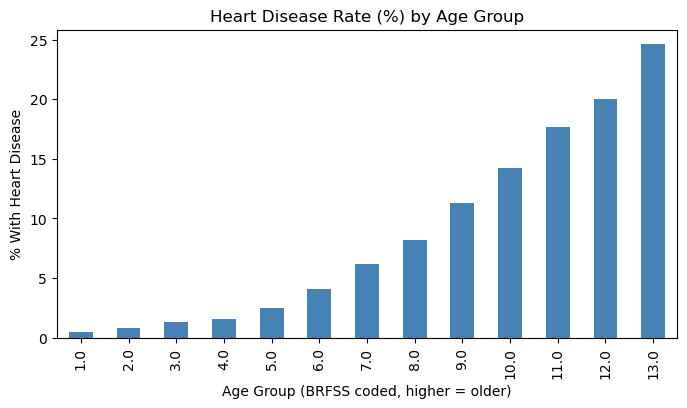

In [13]:
# Heart disease rate (%) by Age group
age_rate = df.groupby("Age")["HeartDiseaseorAttack"].apply(lambda x: round(x.astype(int).mean()*100, 1))
print("Heart disease rate by Age group:")
print(age_rate)

age_rate.plot(kind="bar", color="steelblue", figsize=(8,4))
plt.title("Heart Disease Rate (%) by Age Group")
plt.xlabel("Age Group (BRFSS coded, higher = older)")
plt.ylabel("% With Heart Disease")
plt.show()

Heart disease rate by Sex (0 = Female, 1 = Male in this dataset):
Sex
0.0     7.9
1.0    13.4
Name: HeartDiseaseorAttack, dtype: float64


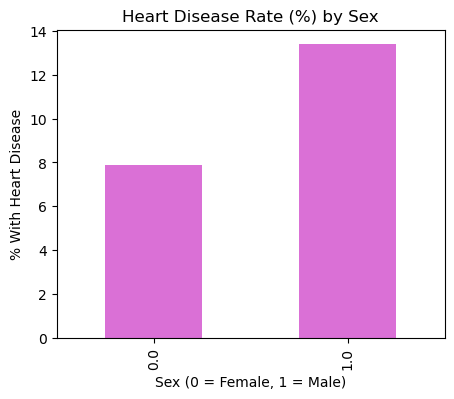

In [14]:
# Heart disease rate (%) by Sex
sex_rate = df.groupby("Sex")["HeartDiseaseorAttack"].apply(lambda x: round(x.astype(int).mean()*100, 1))
print("Heart disease rate by Sex (0 = Female, 1 = Male in this dataset):")
print(sex_rate)

sex_rate.plot(kind="bar", color="orchid", figsize=(5,4))
plt.title("Heart Disease Rate (%) by Sex")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("% With Heart Disease")
plt.show()

Heart disease rate by Income level (1 = lowest, 8 = highest):
Income
1.0    15.9
2.0    18.7
3.0    15.8
4.0    14.2
5.0    12.4
6.0    10.3
7.0     8.4
8.0     6.2
Name: HeartDiseaseorAttack, dtype: float64


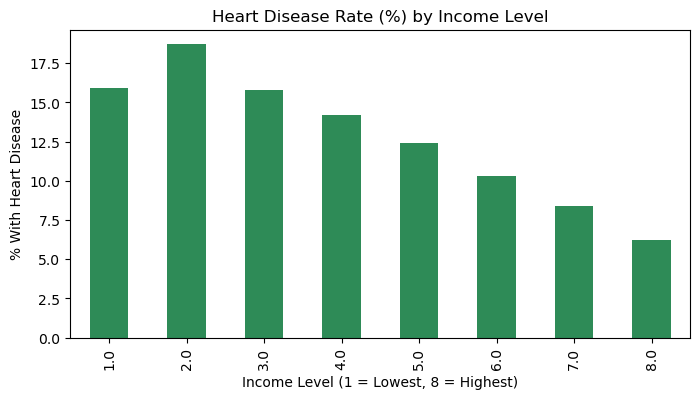

In [15]:
# Heart disease rate (%) by Income level
income_rate = df.groupby("Income")["HeartDiseaseorAttack"].apply(lambda x: round(x.astype(int).mean()*100, 1))
print("Heart disease rate by Income level (1 = lowest, 8 = highest):")
print(income_rate)

income_rate.plot(kind="bar", color="seagreen", figsize=(8,4))
plt.title("Heart Disease Rate (%) by Income Level")
plt.xlabel("Income Level (1 = Lowest, 8 = Highest)")
plt.ylabel("% With Heart Disease")
plt.show()

Heart disease rate by Education level (1 = lowest, 6 = highest):
Education
1.0    16.7
2.0    19.3
3.0    17.1
4.0    12.2
5.0    10.4
6.0     7.9
Name: HeartDiseaseorAttack, dtype: float64


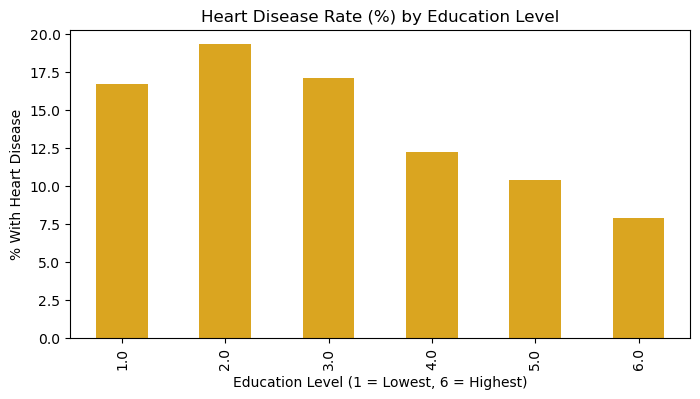

In [16]:
# Heart disease rate (%) by Education level
education_rate = df.groupby("Education")["HeartDiseaseorAttack"].apply(lambda x: round(x.astype(int).mean()*100, 1))
print("Heart disease rate by Education level (1 = lowest, 6 = highest):")
print(education_rate)

education_rate.plot(kind="bar", color="goldenrod", figsize=(8,4))
plt.title("Heart Disease Rate (%) by Education Level")
plt.xlabel("Education Level (1 = Lowest, 6 = Highest)")
plt.ylabel("% With Heart Disease")
plt.show()

##  Which health risk factors matter most?
This is the most important part — instead of just showing charts, we calculate the **exact percentage** of heart disease cases within each risk-factor group. This gives us real numbers to quote, e.g. *"X% of people with high blood pressure had heart disease, vs. Y% of those without."*

In [17]:
# For each risk factor, calculate what % of people in each group (Yes/No) have heart disease
risk_factors = ["HighBP", "HighChol", "Smoker", "Stroke", "DiffWalk", "HvyAlcoholConsump"]

for col in risk_factors:
    pct_table = pd.crosstab(df[col], df["HeartDiseaseorAttack"], normalize="index") * 100
    print(f"\n--- {col} ---")
    print(pct_table.round(1))


--- HighBP ---
HeartDiseaseorAttack   0.0   1.0
HighBP                          
0.0                   95.3   4.7
1.0                   83.0  17.0

--- HighChol ---
HeartDiseaseorAttack   0.0   1.0
HighChol                        
0.0                   94.4   5.6
1.0                   83.6  16.4

--- Smoker ---
HeartDiseaseorAttack   0.0   1.0
Smoker                          
0.0                   92.7   7.3
1.0                   86.3  13.7

--- Stroke ---
HeartDiseaseorAttack   0.0   1.0
Stroke                          
0.0                   91.0   9.0
1.0                   61.7  38.3

--- DiffWalk ---
HeartDiseaseorAttack   0.0   1.0
DiffWalk                        
0.0                   92.6   7.4
1.0                   76.8  23.2

--- HvyAlcoholConsump ---
HeartDiseaseorAttack   0.0   1.0
HvyAlcoholConsump               
0.0                   89.4  10.6
1.0                   93.9   6.1


**How to read this:** for each factor, the table shows what percentage of people in the "No" group (0) and the "Yes" group (1) reported heart disease. A bigger gap between the two rows means that factor is more strongly linked to heart disease in this data.

## A simple combined risk score
Instead of looking at one factor at a time, we can add them up: each person gets a score from 0 to 6 based on how many risk factors they have. Then we check — does heart disease go up as the score goes up?

In [18]:
# Add up how many of the 6 risk factors each person has (0 = none, 6 = all)
df["RiskScore"] = df[risk_factors].astype(int).sum(axis=1)

# For each risk score, what % of people had heart disease?
risk_summary = df.groupby("RiskScore")["HeartDiseaseorAttack"].apply(
    lambda x: round(x.astype(int).mean() * 100, 1)
)
print(risk_summary)

RiskScore
0     1.7
1     4.4
2    10.4
3    19.8
4    31.7
5    48.2
6    49.2
Name: HeartDiseaseorAttack, dtype: float64


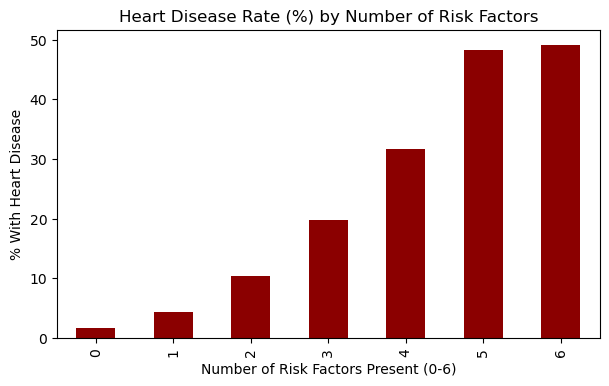

In [19]:
# Plot it — this is usually the single most convincing chart in the whole notebook
risk_summary.plot(kind="bar", color="darkred", figsize=(7,4))
plt.title("Heart Disease Rate (%) by Number of Risk Factors")
plt.xlabel("Number of Risk Factors Present (0-6)")
plt.ylabel("% With Heart Disease")
plt.show()

## Takeaways (filled in with your real results)
1. Duplicates found & removed: 23,899 duplicate rows removed (253,680 → 229,781 clean records)
2. Overall heart disease rate: 10.32% (23,717 out of 229,781 people)
3. Age group with the highest rate: Oldest age group (coded 13) at 24.6% — rate climbs steadily with age, from 0.5% in the youngest group to 24.6% in the oldest
4. Sex: Males 13.4% vs. Females 7.9% — males nearly double the rate
5. Strongest single health risk factor: Stroke — 38.3% of people who've had a stroke also have heart disease, vs. 9.0% of those who haven't (a 29.3 percentage-point gap — the biggest of any factor checked)
5. Other notable gaps: DiffWalk (difficulty walking) 23.2% vs. 7.4% (15.8-pt gap); HighBP 17.0% vs. 4.7% (12.3-pt gap); HighChol 16.4% vs. 5.6% (10.8-pt gap)
6. Combined risk score: rate climbs from 1.7% with 0 risk factors to 49.2% with all 6 — nearly a 29x increase
7. Income: rate falls from ~15.9-18.7% at the lowest income levels down to 6.2% at the highest — clear inverse relationship
Education: rate falls from ~19.3% at lower education levels to 7.9% at the highest
